# 04 — Model Evaluation

Loads the pipelines and test set notebook `03_` saved — no raw data
reloading, no retraining. This notebook's job is evaluation, interpretation,
and business framing only.

## 1. Load saved pipelines and test set

Loading both fitted pipelines and the held-out 2017+ test set from notebook
03's saved artifacts, and restating the population/split summary so this
notebook reads standalone.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import shap

# GarbageValueCleaner/CastToCategory must be importable from the same module
# path notebook 03 pickled them from, or joblib.load fails on unpickling.
sys.path.append(str(Path('..').resolve()))
from src.preprocessing import GarbageValueCleaner, CastToCategory

from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, precision_score, recall_score, f1_score,
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
GOOD_COLOR = '#4C72B0'
BAD_COLOR = '#C44E52'
THIRD_COLOR = '#55A868'


In [2]:
MODELS_DIR = Path('../models')

lgbm_pipeline = joblib.load(MODELS_DIR / 'lgbm_default_risk_pipeline.joblib')
lr_pipeline = joblib.load(MODELS_DIR / 'lr_default_risk_pipeline.joblib')
test_df = pd.read_parquet(MODELS_DIR / 'test_df.parquet')

# test_df was saved as [features + target + issue_d + int_rate + recoveries] --
# drop the non-feature columns to recover exactly what the pipelines expect.
non_feature_cols = ['target', 'issue_d', 'int_rate', 'recoveries']
X_test = test_df.drop(columns=non_feature_cols)
y_test = test_df['target']

print(f"Test set: {len(test_df):,} loans, {test_df['issue_d'].min().date()} to "
      f"{test_df['issue_d'].max().date()}, default rate {y_test.mean():.2%}")

Test set: 225,639 loans, 2017-01-01 to 2018-12-01, default rate 21.29%


## 2. Core metrics: AUC, KS

**KS**, in plain terms: sort applicants by predicted default probability,
then compare the cumulative share of actual defaulters vs. actual
non-defaulters at each cutoff. KS is the largest gap between those two
cumulative curves — the point where the model separates the two groups
best. Higher KS means a cleaner split between who defaults and who doesn't.

In [3]:
def ks_statistic(y_true, y_prob):
    """Max |CDF_bad(p) - CDF_good(p)| -- the textbook credit-risk KS statistic."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bad_scores = np.sort(y_prob[y_true == 1])
    good_scores = np.sort(y_prob[y_true == 0])
    thresholds = np.sort(np.unique(y_prob))
    cum_bad = np.searchsorted(bad_scores, thresholds, side='right') / len(bad_scores)
    cum_good = np.searchsorted(good_scores, thresholds, side='right') / len(good_scores)
    gap = np.abs(cum_bad - cum_good)
    ks_idx = np.argmax(gap)
    return gap[ks_idx], thresholds[ks_idx]

y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_prob_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]

results = []
for name, proba in [('Logistic Regression', y_prob_lr), ('LightGBM', y_prob_lgbm)]:
    ks, ks_at = ks_statistic(y_test, proba)
    results.append({'model': name, 'AUC': roc_auc_score(y_test, proba), 'KS': ks, 'KS_at_score': ks_at})
results_df = pd.DataFrame(results)
results_df

,model,AUC,KS,KS_at_score
0,Logistic Regression,0.69,0.27,0.17
1,LightGBM,0.70,0.29,0.18


LightGBM edges out logistic regression again — AUC 0.70 vs 0.69, KS 0.29 vs
0.27.

## 3. Threshold analysis

A single fixed cutoff like 0.5 isn't natural here — only ~20% of applicants
actually default, so the full threshold range matters more than one or two
points on it.

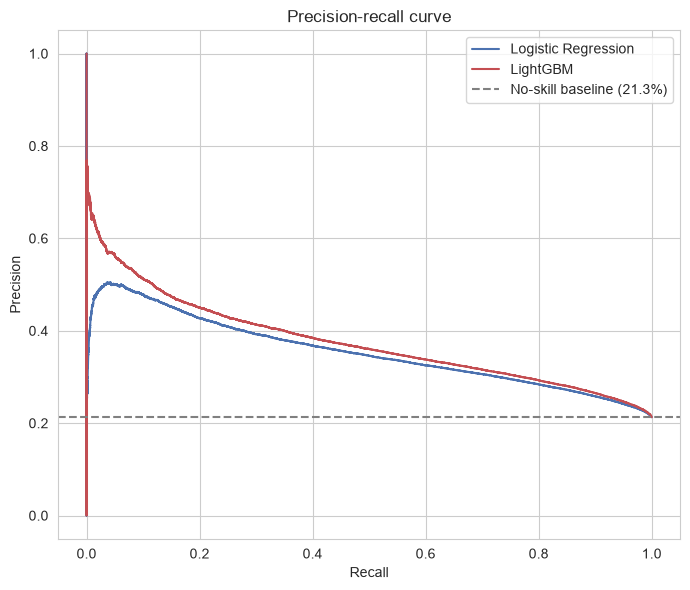

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, proba, color in [('Logistic Regression', y_prob_lr, GOOD_COLOR), ('LightGBM', y_prob_lgbm, BAD_COLOR)]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ax.plot(recall, precision, label=name, color=color)
ax.axhline(y_test.mean(), linestyle='--', color='grey', label=f'No-skill baseline ({y_test.mean():.1%})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-recall curve')
ax.legend()
plt.tight_layout()
plt.show()

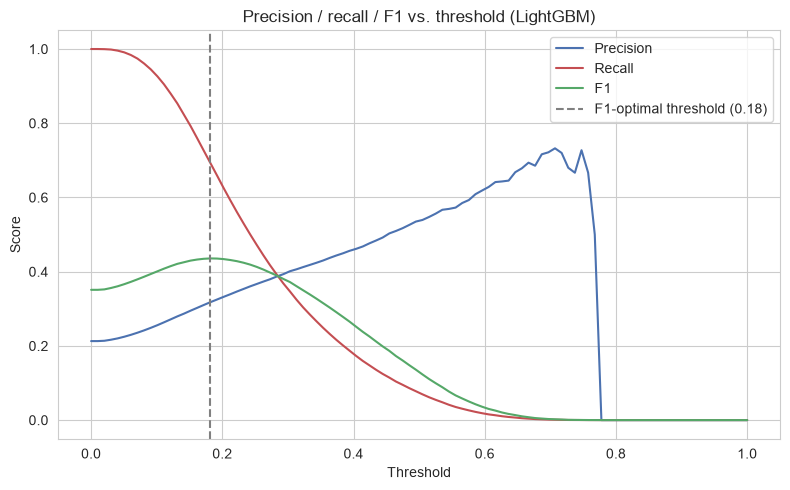

F1-optimal threshold: 0.18


In [5]:
thresholds = np.linspace(0, 1, 100)
sweep = []
for t in thresholds:
    preds = (y_prob_lgbm >= t).astype(int)
    sweep.append({
        'threshold': t,
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall': recall_score(y_test, preds, zero_division=0),
        'f1': f1_score(y_test, preds, zero_division=0),
    })
sweep_df = pd.DataFrame(sweep)
f1_optimal_threshold = sweep_df.loc[sweep_df['f1'].idxmax(), 'threshold']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep_df['threshold'], sweep_df['precision'], label='Precision', color=GOOD_COLOR)
ax.plot(sweep_df['threshold'], sweep_df['recall'], label='Recall', color=BAD_COLOR)
ax.plot(sweep_df['threshold'], sweep_df['f1'], label='F1', color=THIRD_COLOR)
ax.axvline(f1_optimal_threshold, linestyle='--', color='grey',
           label=f'F1-optimal threshold ({f1_optimal_threshold:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / recall / F1 vs. threshold (LightGBM)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'F1-optimal threshold: {f1_optimal_threshold:.2f}')

F1-optimal threshold lands at **0.18** — close to the ~20% base default
rate, not the textbook 0.5. Precision and recall trade off steeply well
below the midpoint: pushing the cutoff toward 0.5 chases precision but
recall collapses, since so few applicants ever score that high. A cutoff
choice here is really a decision about how many good applicants to reject
per defaulter caught — there's no threshold-free "correct" answer, which is
why section 4 reframes it in cost terms instead.

## 4. Expected-cost threshold curve

Business-framed threshold selection instead of a pure statistical criterion.
At each threshold:

`cost(t) = P(false negative at t) * cost_FN + P(false positive at t) * cost_FP`

**Assumptions (stated up front so they can be swapped for real numbers):**
- `cost_FN` (approving an applicant who defaults): average `loan_amnt` among
  test-set defaulters, net of the recovery rate measured directly from the
  saved test set's `recoveries` field (not assumed).
- `cost_FP` (rejecting an applicant who would have repaid): average
  `loan_amnt` among good test-set applicants × their average `int_rate`, as
  a one-period foregone-margin proxy. `int_rate` is used here only as a
  business-cost input, not a model feature — consistent with its exclusion
  from Phase 1 (notebook 03, section 2).

In [6]:
defaulted = test_df[test_df['target'] == 1]
recovery_rate = defaulted['recoveries'].sum() / defaulted['loan_amnt'].sum()
cost_fn = defaulted['loan_amnt'].mean() * (1 - recovery_rate)

good = test_df[test_df['target'] == 0]
cost_fp = good['loan_amnt'].mean() * (good['int_rate'].mean() / 100)

print(f'Measured recovery rate on defaulted test-set loans: {recovery_rate:.1%}')
print(f'Assumed cost of a false negative (missed default): ${cost_fn:,.0f}')
print(f'Assumed cost of a false positive (rejected good applicant): ${cost_fp:,.0f}')

Measured recovery rate on defaulted test-set loans: 6.1%
Assumed cost of a false negative (missed default): $15,048
Assumed cost of a false positive (rejected good applicant): $1,831


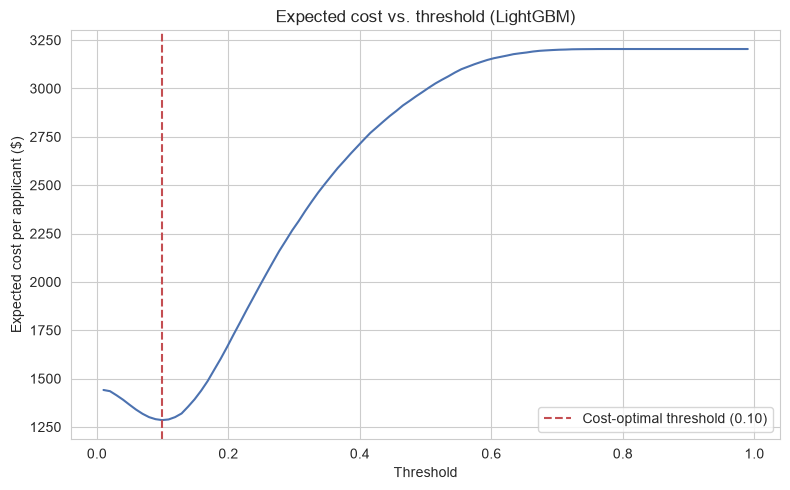

Cost-optimal threshold: 0.10 (vs. F1-optimal: 0.18)


In [7]:
def expected_cost(y_true, y_prob, threshold, cost_fn, cost_fp):
    pred = (y_prob >= threshold).astype(int)
    y_true = np.asarray(y_true)
    fn_rate = ((y_true == 1) & (pred == 0)).mean()
    fp_rate = ((y_true == 0) & (pred == 1)).mean()
    return fn_rate * cost_fn + fp_rate * cost_fp

cost_thresholds = np.linspace(0.01, 0.99, 100)
costs = [expected_cost(y_test, y_prob_lgbm, t, cost_fn, cost_fp) for t in cost_thresholds]
cost_optimal_threshold = cost_thresholds[np.argmin(costs)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cost_thresholds, costs, color=GOOD_COLOR)
ax.axvline(cost_optimal_threshold, linestyle='--', color=BAD_COLOR,
           label=f'Cost-optimal threshold ({cost_optimal_threshold:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Expected cost per applicant ($)')
ax.set_title('Expected cost vs. threshold (LightGBM)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Cost-optimal threshold: {cost_optimal_threshold:.2f} (vs. F1-optimal: {f1_optimal_threshold:.2f})')

The cost-optimal threshold (**0.10**) sits well below the F1-optimal one
(0.18). At the measured 6.1% recovery rate, a missed default costs ~8x a
rejected good applicant ($15,048 vs. $1,831) — so the business-optimal
policy is more conservative than a pure statistical one: better to reject
more marginal-good applicants than miss a defaulter. This ratio is sensitive
to the recovery-rate and margin assumptions above; a materially different
recovery rate or interest margin would shift this threshold, which is why
those inputs are stated explicitly rather than baked in.

## 5. Calibration

A different question from AUC/KS: not "does the model rank applicants
correctly" but "does a predicted probability mean what it says" — a bucket
of applicants predicted at ~15% should show close to a 15% actual default
rate.

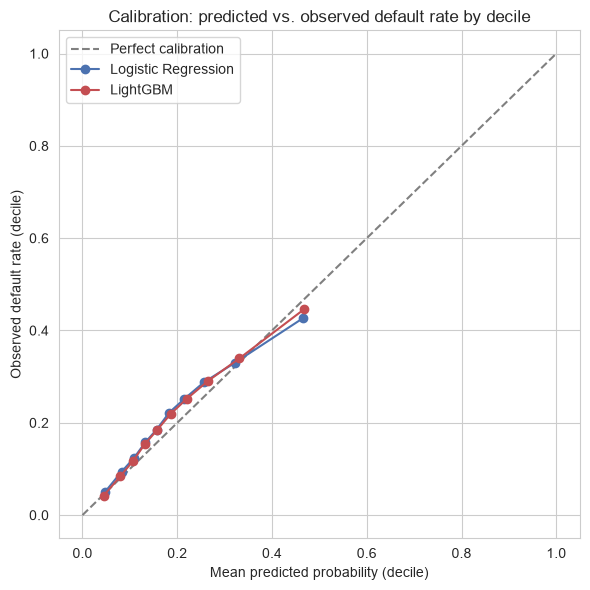

In [8]:
def reliability_table(y_true, y_prob, n_bins=10):
    cal = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(y_prob)})
    cal['bin'] = pd.qcut(cal['p'], n_bins, duplicates='drop')
    return cal.groupby('bin', observed=True).agg(
        mean_predicted=('p', 'mean'), observed_rate=('y', 'mean'), n=('y', 'size'),
    )

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect calibration')
for name, proba, color in [('Logistic Regression', y_prob_lr, GOOD_COLOR), ('LightGBM', y_prob_lgbm, BAD_COLOR)]:
    cal = reliability_table(y_test, proba)
    ax.plot(cal['mean_predicted'], cal['observed_rate'], marker='o', label=name, color=color)
ax.set_xlabel('Mean predicted probability (decile)')
ax.set_ylabel('Observed default rate (decile)')
ax.set_title('Calibration: predicted vs. observed default rate by decile')
ax.legend()
plt.tight_layout()
plt.show()

**Verdict: moderately miscalibrated, not display-ready as-is.** Both models
systematically *underestimate* risk through the middle of the distribution —
LightGBM's largest gap is ~3.3 points (predicted ~18.6%, observed ~21.9% in
one decile), logistic regression's is ~3.9 points — then *overestimate* in
the top decile (predicted ~47%, observed ~43% for LightGBM). A
`CalibratedClassifierCV` wrapper is worth applying before Phase 3 displays
these as literal probabilities; raw output is fine for ranking/thresholding
(sections 3-4) but currently understates risk for a typical applicant.


## 6. Rolling time-based CV stability check

LightGBM's AUC/KS across the 3 rolling folds notebook 03 prepared, loaded
from its saved artifact rather than retrained here. This is a robustness
check connecting to the same "respect chronology" principle Phase 2's
vintage/hazard analysis will build on.

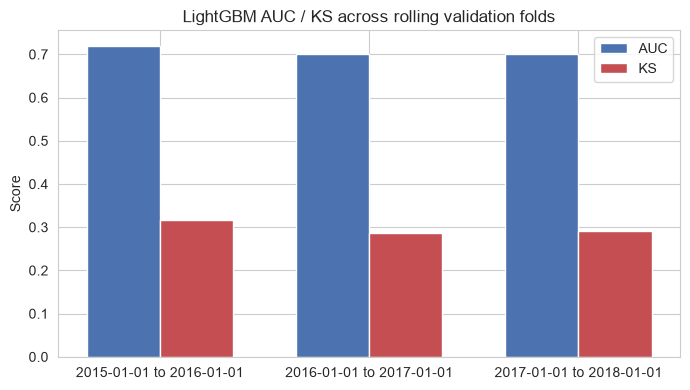

,fold,val_start,val_end,n_val,AUC,KS
0,1,2015-01-01,2016-01-01,375546,0.72,0.32
1,2,2016-01-01,2017-01-01,293105,0.70,0.29
2,3,2017-01-01,2018-01-01,169321,0.70,0.29


In [9]:
rolling_results_df = pd.read_csv(MODELS_DIR / 'lgbm_rolling_cv_results.csv')
rolling_results_df['fold_label'] = rolling_results_df['val_start'] + ' to ' + rolling_results_df['val_end']

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(rolling_results_df))
width = 0.35
ax.bar([i - width / 2 for i in x], rolling_results_df['AUC'], width, label='AUC', color=GOOD_COLOR)
ax.bar([i + width / 2 for i in x], rolling_results_df['KS'], width, label='KS', color=BAD_COLOR)
ax.set_xticks(list(x))
ax.set_xticklabels(rolling_results_df['fold_label'])
ax.set_ylabel('Score')
ax.set_title('LightGBM AUC / KS across rolling validation folds')
ax.legend()
plt.tight_layout()
plt.show()

rolling_results_df[['fold', 'val_start', 'val_end', 'n_val', 'AUC', 'KS']]

Performance is **stable, not drifting** — AUC holds in a tight 0.70-0.72
band and KS in 0.29-0.32 across all three rolling folds, with only a slight
dip from the earliest fold (2015) to the later two. No sign of the model
degrading as it's asked to generalize further forward in time, which is a
reasonable robustness signal given Phase 2's vintage/hazard work will lean
on the same "respect chronology" principle used throughout this project.


## 7. SHAP interpretability (LightGBM)

`shap.TreeExplainer` on the fitted LightGBM model, applied to the exact
preprocessed input it saw — running the pipeline's `preprocess` and
`cast_categorical` steps first, then explaining on that transformed data.

In [10]:
lgbm_model = lgbm_pipeline.named_steps['model']

# lgbm_pipeline[:-1] would raise NotFittedError -- CastToCategory's fit() sets
# no fitted attribute (it's stateless), so sklearn's check_is_fitted can't
# confirm a *sliced* pipeline is fitted even though its steps are. Calling
# the two preprocessing steps directly sidesteps that check entirely.
X_test_transformed = lgbm_pipeline.named_steps['preprocess'].transform(X_test)
X_test_transformed = lgbm_pipeline.named_steps['cast_categorical'].transform(X_test_transformed)

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer(X_test_transformed)


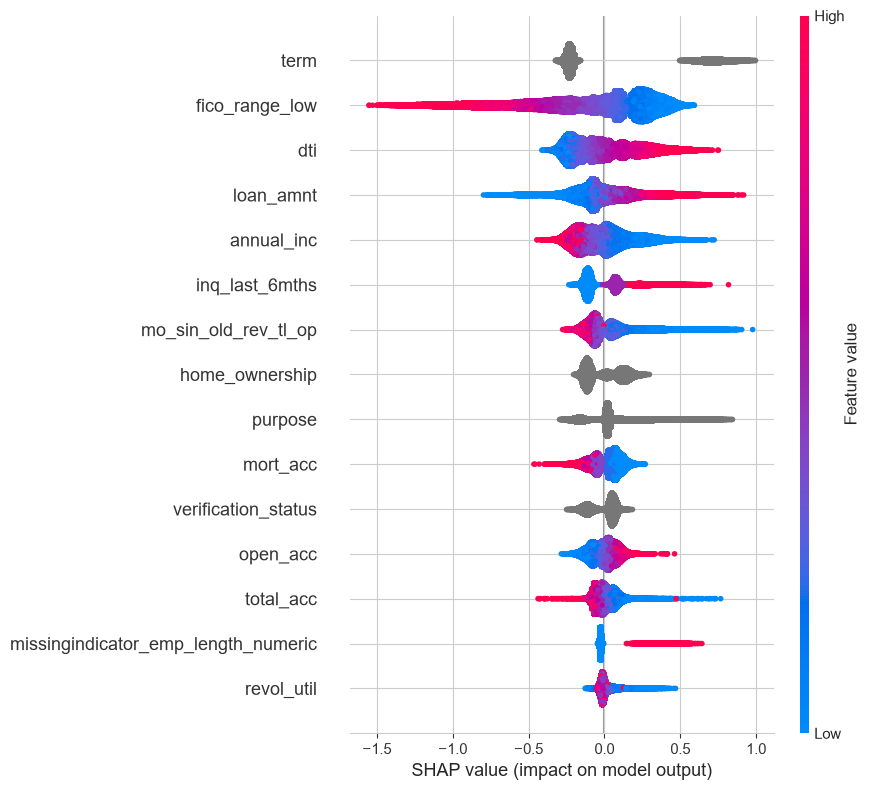

In [11]:
shap.summary_plot(shap_values, X_test_transformed, max_display=15, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 8)
plt.tight_layout()
plt.show()

Comparing SHAP's global ranking (mean absolute SHAP value per feature) to
LightGBM's own gain-based importance -- the method used before SHAP was
introduced here. Gain-based importance has no direction (it can't say
*which way* a feature pushes risk), so `mort_acc`'s sign is checked via SHAP
specifically, against notebook 02's raw-EDA finding that more mortgage
accounts associates with *lower* default risk.

In [12]:
gain_importance = pd.DataFrame({
    'feature': lgbm_model.booster_.feature_name(),
    'gain_importance': lgbm_model.feature_importances_,
}).sort_values('gain_importance', ascending=False).reset_index(drop=True)

shap_importance = pd.DataFrame({
    'feature': X_test_transformed.columns,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

comparison = gain_importance.head(10)[['feature', 'gain_importance']].merge(
    shap_importance.reset_index().rename(columns={'index': 'shap_rank'}),
    on='feature', how='left',
)
comparison['gain_rank'] = comparison.index
comparison[['feature', 'gain_rank', 'gain_importance', 'shap_rank', 'mean_abs_shap']]

,feature,gain_rank,gain_importance,shap_rank,mean_abs_shap
0,term,0,"348,574.43",0,0.35
1,fico_range_low,1,"193,741.75",1,0.32
2,dti,2,"98,465.93",2,0.18
3,mort_acc,3,"54,791.45",9,0.08
4,annual_inc,4,"50,077.61",4,0.14
5,mo_sin_old_rev_tl_op,5,"41,786.20",6,0.12
6,loan_amnt,6,"41,094.43",3,0.16
7,home_ownership,7,"39,387.97",7,0.11
8,inq_last_6mths,8,"37,598.29",5,0.12
9,purpose,9,"31,958.30",8,0.09


In [13]:
mort_acc_idx = list(X_test_transformed.columns).index('mort_acc')
mort_acc_corr = np.corrcoef(X_test_transformed['mort_acc'], shap_values.values[:, mort_acc_idx])[0, 1]
print(f'Correlation between mort_acc value and its SHAP contribution: {mort_acc_corr:.2f}')
print('(negative = higher mort_acc pushes predicted risk down, i.e. protective)')

Correlation between mort_acc value and its SHAP contribution: -0.91
(negative = higher mort_acc pushes predicted risk down, i.e. protective)


**Broad agreement at the top, reshuffling below it.** `term`, `fico_range_low`,
and `dti` rank #1-#3 by both methods, identically ordered. Below that they
diverge: `mort_acc` is #3 by gain but only #9 by mean |SHAP| — gain rewards a
feature for the splits it wins regardless of how much each split actually
moves a prediction, while SHAP measures realized impact on individual
outputs, and this gap is a case where the two disagree materially.
`mort_acc`'s value-vs-SHAP correlation is **-0.91** — strongly confirming
notebook 02's raw-EDA finding that more mortgage accounts is *protective*
(pushes predicted risk down), not risky, despite the intuitive-sounding
feature name.


High-risk applicant (row 191407): predicted default probability = 80.33%


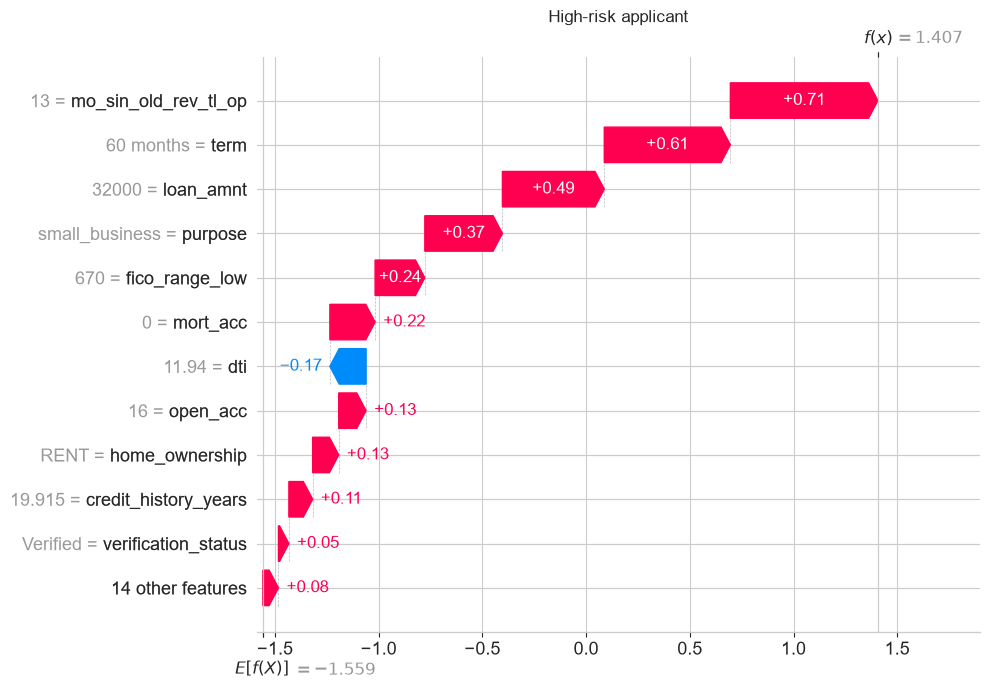

Low-risk applicant (row 113322): predicted default probability = 0.95%


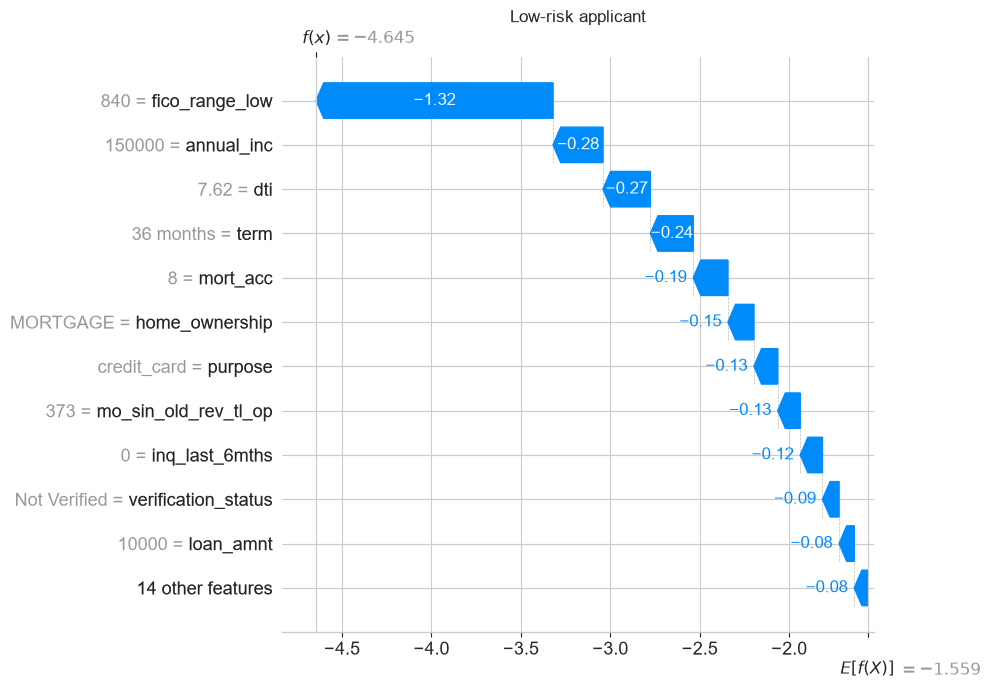

Borderline applicant (row 135684): predicted default probability = 18.18%


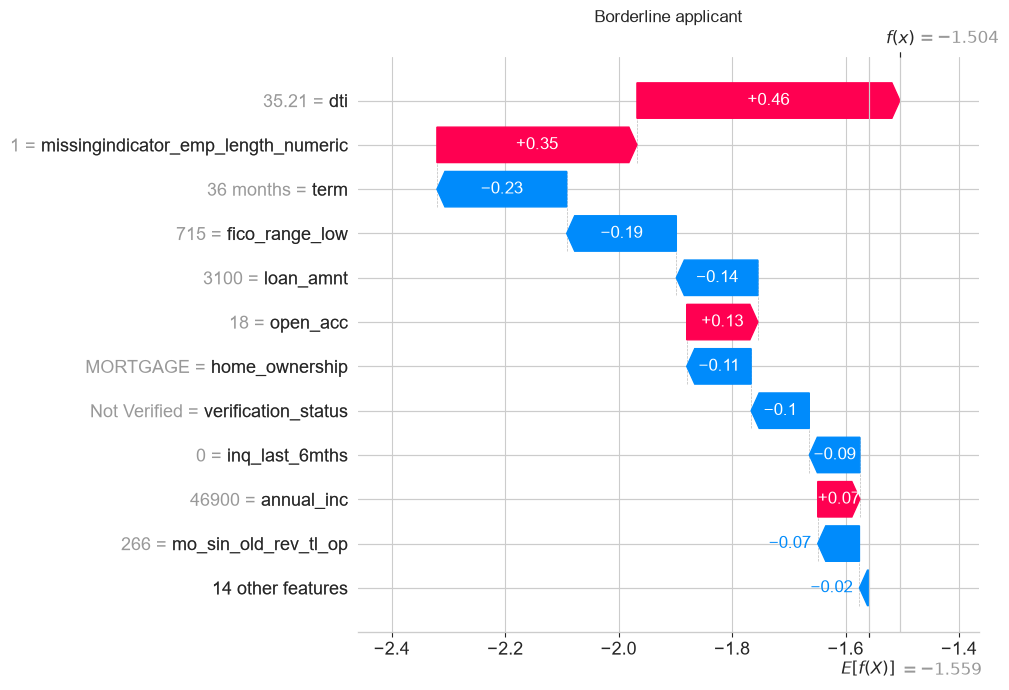

In [14]:
proba_lgbm_full = lgbm_pipeline.predict_proba(X_test)[:, 1]
high_idx = int(np.argmax(proba_lgbm_full))
low_idx = int(np.argmin(proba_lgbm_full))
borderline_idx = int(np.argmin(np.abs(proba_lgbm_full - f1_optimal_threshold)))

for label, idx in [('High-risk', high_idx), ('Low-risk', low_idx), ('Borderline', borderline_idx)]:
    print(f'{label} applicant (row {idx}): predicted default probability = {proba_lgbm_full[idx]:.2%}')
    shap.plots.waterfall(shap_values[idx], max_display=12, show=False)
    fig = plt.gcf()
    fig.set_size_inches(10, 7)
    plt.title(f'{label} applicant')
    plt.tight_layout()
    plt.show()

### `emp_length` missingness: does the indicator carry signal?

Notebook 01's audit found `emp_length` nulls are a distinctly higher-risk
group (27% vs. 21% default rate for `< 1 year`, resolved loans), not random
missingness. `SimpleImputer(strategy='median', add_indicator=True)` exposes
this to the model via a separate `missingindicator_emp_length_numeric`
column rather than silently blending the null group into the median tenure
value — checking here whether the model actually uses it, the same way
`mort_acc`'s direction was checked above.

In [15]:
indicator_col = 'missingindicator_emp_length_numeric'
indicator_idx = list(X_test_transformed.columns).index(indicator_col)

indicator_row = shap_importance[shap_importance['feature'] == indicator_col].iloc[0]
indicator_rank = shap_importance[shap_importance['feature'] == indicator_col].index[0]

indicator_corr = np.corrcoef(
    X_test_transformed[indicator_col], shap_values.values[:, indicator_idx]
)[0, 1]

print(f"{indicator_col}: mean |SHAP| = {indicator_row['mean_abs_shap']:.4f} "
      f"(rank {indicator_rank + 1} of {len(shap_importance)})")
print(f'Correlation between indicator value (1=null) and its SHAP contribution: {indicator_corr:.2f}')
print('(positive = missing emp_length pushes predicted risk up)')

missingindicator_emp_length_numeric: mean |SHAP| = 0.0501 (rank 14 of 25)
Correlation between indicator value (1=null) and its SHAP contribution: 0.99
(positive = missing emp_length pushes predicted risk up)


**Confirmed: the missingness indicator is doing its job.**
`missingindicator_emp_length_numeric` has a **0.99** correlation between its
value and its SHAP contribution — nearly as clean a signal as `mort_acc`'s
-0.91 above, and in the direction notebook 01's audit predicted: missing
`emp_length` pushes predicted risk *up*. It ranks only 14th of 25 features
by mean |SHAP| (emp_length overall is a weaker predictor than
`term`/`fico_range_low`/`dti`), but the direction and strength confirm the
model treats the null group as meaningfully riskier rather than blending it
into the median tenure value.

## 8. Notebook summary

- **Performance:** LightGBM AUC 0.70 / KS 0.29 vs. logistic regression AUC
  0.69 / KS 0.27.
- **Recommended threshold:** the cost-optimal cutoff (**0.10**) is preferred
  over the F1-optimal one (0.18) — missing a default costs ~8x rejecting a
  good applicant at the measured 6.1% recovery rate, so the business-optimal
  policy is more conservative than a pure statistical one.
- **Calibration:** moderately miscalibrated — both models underestimate risk
  through the middle deciles (up to ~3.9 points) and overestimate at the top.
  A `CalibratedClassifierCV` wrapper is recommended before Phase 3 displays
  raw probabilities. Notebook 04b applies and evaluates this fix directly —
  see it for the actual before/after numbers and a controlled test of the
  cause (the feature expansion turned out not to be it).
- **Stability:** AUC/KS stay in a tight band (0.70-0.72 / 0.29-0.32) across
  all 3 rolling time folds — no drift, a reasonable robustness signal for
  Phase 2's chronology-respecting approach.
- **What drives risk:** `term`, `fico_range_low`, and `dti` dominate both
  SHAP and gain-based rankings, identically ordered — essentially rebuilding,
  from raw application-time inputs, the same risk signal `grade` (excluded
  for leakage reasons) already encoded. `mort_acc` is the standout: ranked
  #3 by gain but confirmed by SHAP to be genuinely protective (r=-0.91), not
  risky — a case where gain-based importance alone would have been
  misleading about direction.
- **`emp_length` missingness indicator:** confirmed carrying real signal —
  0.99 correlation between the indicator and its SHAP contribution, in the
  risk-increasing direction notebook 01's audit predicted (27% vs. 21%
  default rate for null vs. `< 1 year`). The existing
  `SimpleImputer(add_indicator=True)` setup was already sufficient; no
  pipeline change needed.